In [ ]:
import pandas as pd
import cnsplots as cns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.image as mpimg
import numpy as np
from matplotlib.colors import to_rgb, to_hex
from collections import defaultdict

In [44]:
# define constants
COLNAME = "assigned_subcat" # hierarchy level to be analyzed, from here on defined as 'subcategory'
COLNAME_MAP = "Subcategory" # respective column name in the mapping file
TOP_COLNAME = "assigned_top" # hierarchy level to serve as top-level category/mapping
TOP_COLNAME_MAP = "Top_Category" # respective column name in the mapping file
SEQ_ID = 0.95 # sequence identity threshold used for clustering (part of input data file name)

# assertions
assert COLNAME and TOP_COLNAME in ["assigned_subcat", "assigned_cat", "assigned_top"], "Invalid column name. Must be one of 'assigned_subcat', 'assigned_cat', or 'assigned_top'."
assert COLNAME_MAP and TOP_COLNAME_MAP in ["Subcategory", "Category", "Top_Category"], "Invalid column name. Must be one of 'Subcategory', 'Category', or 'Top_Category'."
assert SEQ_ID in [0.95, 0.2], "Invalid sequence identity threshold. Must be one of 0.95, 0.2."

In [45]:
#######################
# plotting utilities 
#######################

# define colors for top-level categories
topcat_colors = {
    "Assembly": "#007BFF",
    "Structural": "#1e00ff",
    "Host takeover": "#2fff00",
    "NA processing": "#00ffb7",
    "Replication":"#00d9ff",
    "Translation": "#f6ff00",
    "AMGs": "#ffbf00", #"#ffa200",
    "Lysis": "#ff0000", 
    "Anti-Defense": "#ff00dd", 
    "Effectors": "#8e01f9", 
    "Lysogeny": "#FF5A00", #"#ff007b",
    "Unknown": "#bdbdbd", 
}

# define colors for mid-level categories
cat_colors = {
    "Transcriptional regulation": "#2fff00",
    "Transcriptional inhibition": "#02d136",
    "Host resource takeover": "#39fa69",
    "Transcriptional antitermination": "#60c006",
    "Host takeover via phosphorylation": "#3ea52e", 
    "Lytic switch": "#74d216",
    "Transcription factor": "#3C6D0F",
    "Transcriptional machinery": "#0D6806",

    "Integration": "#00ffb7",
    "Excision and transcriptional regulation": "#0dd09c",
    "DNA repair": "#0D916D",
    "Recombination": "#036D51",
    "RNA modification": "#71F8D4",
    "RNA cleavage": "#37F9AF",
    "RNA sealing": "#14AC72",

    "Maintenance": "#FF5A00", #"#ff007b",

    "Protein synthesis": "#f4fa51",
    "Ribosomal protein": "#f3fb00",
    "Translation regulation": "#d0d703",
    "Ribosome biogenesis": "#a0a512",
    "Protein maturation and folding": "#FFFF00",

    "Head morphogenesis": "#4099F9",
    "Head-to-tail joining": "#74B7FE",
    "Tail assembly": "#0F559F",
    "Baseplate assembly": "#014894",
    "DNA packaging": "#0E437B",

    "Replication initiation":"#00d9ff",
    "DNA replication":"#3AAEC3",

    "Capsid": "#1e00ff",
    "DNA injection": "#1903c1",
    "Tail and Fibers": "#553ffb",
    "Baseplate": "#3c2dad",

    "Host polysaccharide degradation": "#e24141", 
    "Endolysin": "#ff0000", 
    "Spanin": "#a90202", 
    "Lysis regulation": "#7D1C1C", 

    "Anti-Restriction": "#ff00dd", 
    "Anti-TA": "#e634f6", 
    "Anti-Defense": "#df00fd",

    "Nucleotide metabolism": "#ffbf00",
    "Other AMGs": "#ff9100",

    "Virulence factors": "#af01f9", 
    "Stress response and damage protection": "#7d01f9", 
    "Membrane transport and signaling": "#a312c3", 
    "Superinfection exclusion": "#710589", 

    "Unknown": "#bdbdbd", 
}


def adjust_color(color, factor=0.2, lighten=True):
    """Mix a color with white or black. The closer the value to 1, the more white/black contained"""
    r, g, b = to_rgb(color)

    if lighten:
        r = r + (1-r)*factor
        g = g + (1-g)*factor
        b = b + (1-b)*factor
    else:
        r = r * (1-factor)
        g = g * (1-factor)
        b = b * (1-factor)

    return to_hex((r, g, b))


def get_factor_range(n, min_n=2, max_n=20, min_spread=0.1, max_spread=0.5):
    """Returns factor range depending on n"""
    # normalize n to 0-1
    t = min(1, max(0, (n - min_n) / (max_n - min_n)))

    spread = min_spread + t * (max_spread - min_spread)

    base = 0.15 
    return base, base+spread


def generate_subcategory_colors(topcat_colors, cat_to_top):
    """Generate colors for subcategories based on their top-level category colors."""
    top_to_sub = defaultdict(list)
    for sub, top in cat_to_top.items():
        top_to_sub[top].append(sub)

    sub_colors = {}

    for top, subs in top_to_sub.items():
        base_color = topcat_colors.get(top, "#999999")
        n = len(subs)

        low, high = get_factor_range(n)

        if n == 1:
            factors = [0.2]
        else:
            factors = np.linspace(low, high, n)

        for i, (sub, factor) in enumerate(zip(subs, factors)):
            lighten = (i % 2 == 0) # alternate
            sub_colors[sub] = adjust_color(base_color, factor, lighten)

    return sub_colors

# lighten top-level category colors
topcat_colors_adjusted = {
    k: adjust_color(v, factor=0.2, lighten=True)
    for k, v in topcat_colors.items()
}

In [46]:
#######################
# Panel B: barplot PhageOnly
#######################

# read mapping file for keywords to sub-, mid-, and top-level categories
keywords_map = pd.read_csv("./input_data/Category_map.csv") 

# create a mapping from subcategories to top-level categories
cat_to_top = keywords_map[[COLNAME_MAP, TOP_COLNAME_MAP]].drop_duplicates().set_index(COLNAME_MAP)[TOP_COLNAME_MAP].to_dict()

def clean_df(df, colname):
    """"Helper function to clean the dataframe by replacing entries with semicolons in the specified column with 'Unknown'."""
    mask = df[colname].str.contains(";")
    df.loc[mask, colname] = "Unknown"
    return df

# read in dataframe and clean it
phage_repr = pd.read_csv(f"./input_data/PhageOnly_new_representatives_assigned_cat_{SEQ_ID}.tsv", sep="\t") # only phage representatives
phage_repr = clean_df(phage_repr, COLNAME)

# get counts of subcategories, excluding "Unknown"
phage_counts = phage_repr[COLNAME].value_counts()

def counts_to_df(vc):
    """Helper function to convert a value counts series to a dataframe."""
    return vc.rename("count").reset_index().rename(columns={"index": COLNAME})

# convert counts to dataframe
df_phage_counts = counts_to_df(phage_counts)

# map subcategories to top-level categories
if COLNAME != "assigned_top":
    df_phage_counts[TOP_COLNAME] = df_phage_counts[COLNAME].map(cat_to_top)
else: 
    df_phage_counts[TOP_COLNAME] = df_phage_counts[COLNAME]

# exclude Unknowns for further analysis
df_phage_counts = df_phage_counts[df_phage_counts[COLNAME] != "Unknown"]

# map subcategories to top-level categories and aggregate counts
df_phage_top_mapped = (
    df_phage_counts.groupby(TOP_COLNAME, as_index=False)["count"]
      .sum()
      .sort_values("count", ascending=False)
)

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

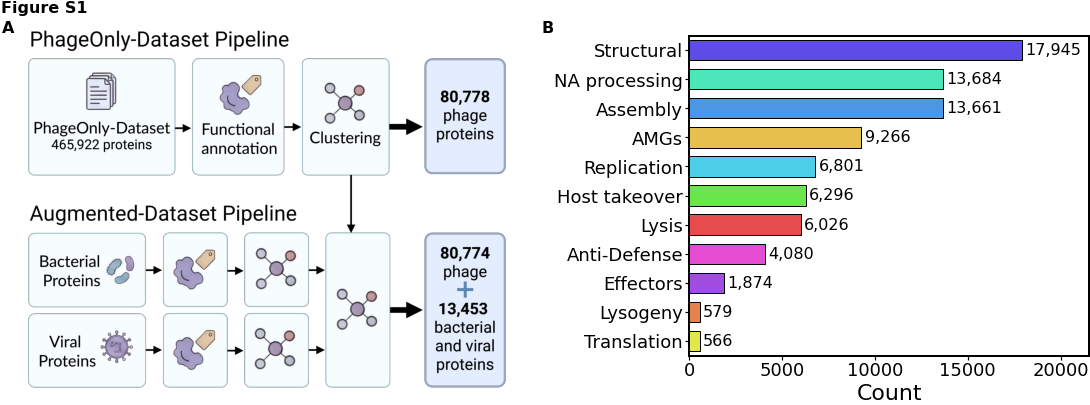

In [47]:
cns.settings.title_fontweight = "normal"
mp = cns.multipanel(
    max_width=600, title="Figure S1", title_fontweight="bold", loc="left"
)

######################
# Panel A: Schematic representation of classification approach
mp.panel("A", 240, 160)
ax = plt.gca()
ax.set_axis_off()

img1 = mpimg.imread("./plots/FigureS1A.png")
ax1 = ax.inset_axes([-0.12, -0.12, 1.18, 1.18])
ax1.imshow(img1)
ax1.set_axis_off()

######################
# Panel B: PhageOnly-Dataset subcategory counts aggregated at the top level
mp.panel("B", 200, 160)
ax = cns.barplot(
    data=df_phage_top_mapped, x="count", y=TOP_COLNAME, palette=topcat_colors_adjusted, hue=TOP_COLNAME, legend=False, errorbar=None, edgecolor="black", width=0.7, lw=0.5
)
# Add counts next to bars
offset = df_phage_top_mapped["count"].max() * 0.01
for i, count in enumerate(df_phage_top_mapped["count"]):
    ax.text(count+offset,   # distance from end of bar
        i, f"{count:,}", va="center", fontsize=8)

ax.set_xlim(right=df_phage_top_mapped["count"].max() * 1.2)
ax.set_xlabel("Count", fontsize=11)
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)

# customize axes
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

ax.set_title("")


# Save final figure
outdir = Path("./plots/")
outdir.mkdir(parents=True, exist_ok=True)
cns.savefig(outdir / "FigureS1.svg")